# Tutorial de estruração populacional

Este tutorial irá guia-lo para realizar as análises de PCA - Análise de Componentes Principais ou Principal Component Analysis - e a estimativa de proporções de ancestralidade individual com o software Admixture para investigar a estrutura populacional.

# Seção 0: Preparação do ambiente do Google Colab
Como feito nos tutoriais anteriores, para que eles funcionem de forma adequada é necessário dar acesso ao Google Drive, onde arquivos e scripts estão localizados, bem como a instalação do Conda e dos pacotes que serão utilizados.

 ❗ **Esses passos são necessários sempre que ocorrer algum período de inatividade ou começo de nova aula prática.**

In [ ]:
# Habilitar o acesso ao Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Criação de uma variável para o diretório base
base_dir = "drive/MyDrive/PopGen_UFMG_2026"

Mounted at /content/drive


In [ ]:
# Instalar Miniconda (1–2 min)
import os

miniconda_installer = f"{base_dir}/miniconda/Miniconda3-latest-Linux-x86_64.sh"
if not os.path.exists(miniconda_installer):
    !wget -P "{base_dir}/miniconda" https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh

!bash "{miniconda_installer}" -bfp /usr/local

# Add conda to the environment
import os
os.environ['PATH'] = '/usr/local/bin:' + os.environ['PATH']

!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r

PREFIX=/usr/local
Unpacking bootstrapper...
Unpacking payload...

Installing base environment...

Preparing transaction: ...working... done
Executing transaction: ...working... done
installation finished.
    You currently have a PYTHONPATH environment variable set. This may cause
    unexpected behavior when running the Python interpreter in Miniconda3.
    For best results, please verify that your PYTHONPATH only points to
    directories of packages that are compatible with the Python interpreter
    in Miniconda3: /usr/local
accepted Terms of Service for https://repo.anaconda.com/pkgs/main
accepted Terms of Service for https://repo.anaconda.com/pkgs/r


In [ ]:
# Criação do ambiente Conda e instalação dos programas necessários
!conda create -n structure -c bioconda -c conda-forge -y plink admixture

Jupyter detected...
2 channel Terms of Service accepted
Retrieving notices: - \ done
Channels:
 - bioconda
 - conda-forge
 - defaults
Platform: linux-64
Solving environment: - \ done

## Package Plan ##

  environment location: /usr/local/envs/structure

  added / updated specs:
    - admixture
    - plink


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    _openmp_mutex-4.5          |           20_gnu          28 KB  conda-forge
    admixture-1.3.0            |                0         832 KB  bioconda
    libgcc-15.2.0              |      he0feb66_19        1017 KB  conda-forge
    libgfortran-15.2.0         |      h69a702a_19          27 KB  conda-forge
    libgfortran5-15.2.0        |      h68bc16d_19         2.4 MB  conda-forge
    libgomp-15.2.0             |      he0feb66_19         590 KB  conda-forge
    libopenblas-0.3.33         |pthreads_h94d23a6_0         5.7 MB  conda

In [ ]:
# Teste do ambiente
!conda run -n structure plink --version
!conda run -n structure admixture --version

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)
****                   ADMIXTURE Version 1.3.0                  ****
****                    Copyright 2008-2015                     ****
****           David Alexander, Suyash Shringarpure,            ****
****                John  Novembre, Ken Lange                   ****
****                                                            ****
****                 Please cite our paper!                     ****
****   Information at www.genetics.ucla.edu/software/admixture  ****

1.3.0


---
# Seção 1: Estrutura populacional
Para avaliar a presença de **isolamento**, **conectividade** e **proporção de fluxo gênico** entre os indivíduos de preguiça de coleira do Norte e do Sul, utilizaremos duas das abordagens apresentadas na aula teórica:

- Análise de Componentes Principais (PCA, *Principal Component Analysis*)

- Proporção de ancestralidade global

❗ **Os comandos abaixo devem ser todos executados em ORDEM, para evitar erros de leitura e perda de etapas intermediárias.**

---
## 1. Dados e softwares
Nesse momento do curso, já realizamos o processamento inicial dos dados, geramos e filtramos o arquivo VCF, que é o formato principal necessário para realizar análises de estrutura populacional. Além disso, também precisamos de um arquivo com informações (metadados) das amostras utilizadas, especialmente para plotar e interpretar os resultados. Os programas que utilizaremos serão o [PLINK](https://www.cog-genomics.org/plink/2.0/) e o [Admixture](https://dalexander.github.io/admixture/admixture-manual.pdf), além de script em Python, que já instalamos acima na parte de configuração do ambiente colab.

    ✍ Resumindo, para realizar essas análises, são necessários:
        📂 Arquivo VCF
        📂 Arquivo de metadados
        💻 Software PLINK
        💻 Software Admixture
        💻 Python

In [ ]:
# Ler arquivo vcf e metadados
vcf_file = f"{base_dir}/Material/vcf/bradypus_chr_14_15.vcf.gz"
metadata = f"{base_dir}/Material/metadata/metadata.csv"

# Nomes e caminhos dos arquivos de saida
name = "bradypus"
out_dir_plink = f"{base_dir}/analyses/06_PopStructure/plink"
out_dir_admx = f"{base_dir}/analyses/06_PopStructure/admixture"

os.makedirs(out_dir_plink, exist_ok=True)
os.makedirs(out_dir_admx, exist_ok=True)

---
## 2. Rodando PLINK

Como visto na aula teórica, o [PLINK](https://pmc.ncbi.nlm.nih.gov/articles/PMC3014363/) é uma ferramenta com uma diversidade de funções para analisar dados de genótipo, fenótipo e suas associações. Aqui nesse tutotial, usaremos ele para:
- Realizar filtros nos dados de SNPs
- Gerar arquivos intermediários para análises seguintes
- Estimar PCA baseada em matriz de covariância GRM (*genetic relationship matrix*)

Abaixo a explicação de **parâmetros que se repetem (comuns)** nos comandos que usaremos ao rodar o PLINK:

* `--vcf:` input VCF file.
* `--double-id:` when you dont have pedigree/family data, then it'll just double the IDs' names.
* `--allow-extra-chr:` allow different chromosomes than expected in humans.
* `--set-missing-var-ids @:#:` since our SNPs are not annotated it'll stands "chromosome:position" as SNP ID
* `--out:` output prefix name.



#### 2.1) Estimar desequilíbrio de ligação
Importante para remover sítios [potencialmente ligados](https://www.cog-genomics.org/plink/1.9/ld), pois podem vir a gerar viéses nos resultados.

Abaixo a explicação dos parâmetros usados:

    --indep-pairwise 50 10 0.1 : windows of 50 SNPs, step size of 10 SNPs, prune sites with r2 greater than 0.1


In [ ]:
# Rodar PLINK para estimar sítios ligados
!conda run -n structure \
plink --vcf {vcf_file} --out {out_dir_plink}/{name}_ld \
--indep-pairwise 50 10 0.1 --allow-extra-chr -double-id --set-missing-var-ids @:#

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to drive/MyDrive/PopGen_UFMG_2026/analyses/06_PopStructure/plink/bradypus_ld.log.
Options in effect:
  --allow-extra-chr
  --double-id
  --indep-pairwise 50 10 0.1
  --out drive/MyDrive/PopGen_UFMG_2026/analyses/06_PopStructure/plink/bradypus_ld
  --set-missing-var-ids @:#
  --vcf drive/MyDrive/PopGen_UFMG_2026/Material/vcf/bradypus_chr_14_15.vcf.gz

12975 MB RAM detected; reserving 6487 MB for main workspace.

--vcf: 1k variants complete.
--vcf: 2k variants complete.
--vcf: 3k variants complete.
--vcf: 4k variants complete.
--vcf: 5k variants complete.
--vcf: 6k variants complete.
--vcf: 7k variants complete.
--vcf: 8k variants complete.
--vcf: 9k variants complete.
--vcf: 10k variants complete.
--vcf: 11k variants complete.
--vcf: 12k variants complete.
--vcf: 13k variants complete.
--vcf: 14k variants complete.
--vcf: 1

In [ ]:
# Ver quais arquivos foram gerados
!ls {out_dir_plink}/{name}_ld*

drive/MyDrive/PopGen_UFMG_2026/analyses/06_PopStructure/plink/bradypus_ld.log
drive/MyDrive/PopGen_UFMG_2026/analyses/06_PopStructure/plink/bradypus_ld.nosex
drive/MyDrive/PopGen_UFMG_2026/analyses/06_PopStructure/plink/bradypus_ld.prune.in
drive/MyDrive/PopGen_UFMG_2026/analyses/06_PopStructure/plink/bradypus_ld.prune.out


Os arquivos gerados contém:
- `*.prune.in`: lista de sítios não ligados;
- `*.prune.out`: lista de sítios ligados;
- `*.log`: log da corrida;
- `*.nosex`: lista de indivíduos com sexo desconhecido


In [ ]:
# Ver o conteúdo do arquivo de sitios nao-ligados
!head {out_dir_plink}/{name}_ld.prune.in

manual_scaffold_14:11126
manual_scaffold_14:62911
manual_scaffold_14:120027
manual_scaffold_14:176903
manual_scaffold_14:242921
manual_scaffold_14:314271
manual_scaffold_14:340537
manual_scaffold_14:392564
manual_scaffold_14:457475
manual_scaffold_14:593129


In [ ]:
# Ver numero de sitios nao-ligados e ligados
!wc -l {out_dir_plink}/{name}_ld.prune.in {out_dir_plink}/{name}_ld.prune.out

   4952 drive/MyDrive/PopGen_UFMG_2026/analyses/06_PopStructure/plink/bradypus_ld.prune.in
 197164 drive/MyDrive/PopGen_UFMG_2026/analyses/06_PopStructure/plink/bradypus_ld.prune.out
 202116 total


In [ ]:
# Ver arquivo log
!cat {out_dir_plink}/{name}_ld.log

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)
Options in effect:
  --allow-extra-chr
  --double-id
  --indep-pairwise 50 10 0.1
  --out drive/MyDrive/PopGen_UFMG_2026/analyses/06_PopStructure/plink/bradypus_ld
  --set-missing-var-ids @:#
  --vcf drive/MyDrive/PopGen_UFMG_2026/Material/vcf/bradypus_chr_14_15.vcf.gz

Hostname: 858ad993d7f1
Working directory: /content
Start time: Thu Jun  4 01:05:29 2026

Random number seed: 1780535129
12975 MB RAM detected; reserving 6487 MB for main workspace.
--vcf:
drive/MyDrive/PopGen_UFMG_2026/analyses/06_PopStructure/plink/bradypus_ld-temporary.bed
+
drive/MyDrive/PopGen_UFMG_2026/analyses/06_PopStructure/plink/bradypus_ld-temporary.bim
+
drive/MyDrive/PopGen_UFMG_2026/analyses/06_PopStructure/plink/bradypus_ld-temporary.fam
written.
202116 variants loaded from .bim file.
202116 missing IDs set.
10 people (0 males, 0 females, 10 ambiguous) loaded from .fam.
Ambiguous sex IDs written to
drive/MyDrive/PopGen_UFMG_2026/analyses/06_PopStructure/plink/bradypus_

#### 2.2) Calcular PCA e arquivos intermediários para Admixture

Primeiramente, investigaremos a estrutura populacional utilizando a Análise de Componentes Principais (PCA).

A PCA é uma técnica estatística que tem como objetivo identificar os principais eixos de variação presentes em um conjunto de dados, sendo que cada eixo é independente dos demais. O primeiro componente principal resume a maior fonte de variação observada nos dados; o segundo componente representa a segunda maior fonte de variação, e assim sucessivamente, até que toda a variação cumulativa seja explicada.

No contexto de dados genômicos, a PCA resume os principais eixos de variação nas frequências alélicas entre indivíduos ou populações, permitindo identificar padrões de estrutura populacional, agrupamentos genéticos e possíveis eventos de mistura genética.

Agora vamos rodar o Plink novamente para realizar a [PCA](https://www.cog-genomics.org/plink/1.9/strat#pca).

Abaixo a explicação dos parâmetros usados:

* `--extract :` use only this list of sites.
* `--make-bed :` create the bed, bim and fam files as output.
* `--pca :` calculate eigenvalues and eigenvectors.

In [ ]:
# Rodar PLINK aplicando filtro de LD
!conda run -n structure \
plink --vcf {vcf_file} -out {out_dir_plink}/{name}.pruned \
--extract {out_dir_plink}/{name}_ld.prune.in --make-bed --pca 10 \
--allow-extra-chr -double-id --set-missing-var-ids @:#

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to drive/MyDrive/PopGen_UFMG_2026/analyses/06_PopStructure/plink/bradypus.pruned.log.
Options in effect:
  --allow-extra-chr
  --double-id
  --extract drive/MyDrive/PopGen_UFMG_2026/analyses/06_PopStructure/plink/bradypus_ld.prune.in
  --make-bed
  --out drive/MyDrive/PopGen_UFMG_2026/analyses/06_PopStructure/plink/bradypus.pruned
  --pca 10
  --set-missing-var-ids @:#
  --vcf drive/MyDrive/PopGen_UFMG_2026/Material/vcf/bradypus_chr_14_15.vcf.gz

12975 MB RAM detected; reserving 6487 MB for main workspace.

--vcf: 1k variants complete.
--vcf: 2k variants complete.
--vcf: 3k variants complete.
--vcf: 4k variants complete.
--vcf: 5k variants complete.
--vcf: 6k variants complete.
--vcf: 7k variants complete.
--vcf: 8k variants complete.
--vcf: 9k variants complete.
--vcf: 10k variants complete.
--vcf: 11k variants complete.


In [ ]:
# Listar arquivos gerados
!ls {out_dir_plink}/{name}.pruned*

drive/MyDrive/PopGen_UFMG_2026/analyses/06_PopStructure/plink/bradypus.pruned.bed
drive/MyDrive/PopGen_UFMG_2026/analyses/06_PopStructure/plink/bradypus.pruned.bim
drive/MyDrive/PopGen_UFMG_2026/analyses/06_PopStructure/plink/bradypus.pruned.eigenval
drive/MyDrive/PopGen_UFMG_2026/analyses/06_PopStructure/plink/bradypus.pruned.eigenvec
drive/MyDrive/PopGen_UFMG_2026/analyses/06_PopStructure/plink/bradypus.pruned.fam
drive/MyDrive/PopGen_UFMG_2026/analyses/06_PopStructure/plink/bradypus.pruned.log
drive/MyDrive/PopGen_UFMG_2026/analyses/06_PopStructure/plink/bradypus.pruned.nosex


Conteúdo dos arquivos gerados:
- `*.bed`, arquivo binario de genótipo, usado no Admixture;
- `*.bim`, informações sobre os sítios, usado no Admixture;
- `*.eigenval`, eigenvalues para PCA;
- `*.eigenvec`, eigenvectors para PCA;
- `*.fam`, informações sobre o pedigree dos indivíduos, usado no Admixture;
- `*.log`, log da corrida;
- `*.nosex`, indivíduos com sexo desconhecido

#### 2.3) Plotar PCA
Agora é só fazer o gráfico! O resultado da PCA está nos arquivos `*.eigenval` e `*.eigenvec`. Já vimos sobre em aula teórica, mas vamos conferir eles aqui diretamente.

✍ **eigenvectors:** valores de cada PC, ordenado pela sua relevância. No arquivo `*.eigenvec`, vemos esse resultado de forma tabular, sendo as duas primeiras colunas identificadores de pedigree e indivíduo,e os demais correspondem ao número de PCs solicitados na flag `--pca`.

✍ **eigenvalues:** valor de relevância de cada PC, ordenado em lista do maior para o menor no arquivo `*.eigenval`, ditando a ordem dos valores de PCs mostrados no arquivo `*.eigenvec`.

In [ ]:
# Ver conteudo do arquivo eigenvec
!cat {out_dir_plink}/{name}.pruned.eigenvec

BT04 BT04 0.316165 -0.0130197 0.605722 0.564651 0.201525 -0.196141 -0.175954 -0.00211671 0.00143278 -0.322632
BT05 BT05 0.320854 0.0147595 -0.33294 -0.293278 0.520779 0.202814 -0.509377 0.0698224 0.0658306 -0.3449
BT17 BT17 0.314818 0.0246422 -0.42697 0.280906 -0.699689 -0.0351834 -0.227484 -0.0079747 -0.098759 -0.294451
BT19 BT19 0.317039 -0.00344619 -0.317552 0.0506301 0.253212 -0.21696 0.758381 -0.0839739 0.0229138 -0.319635
BTPF17 BTPF17 -0.316891 -0.210425 0.0267539 -0.240214 -0.0246038 -0.433408 -0.167329 -0.678011 -0.112071 -0.328903
BTPF22 BTPF22 -0.315499 -0.225212 -0.0229823 0.17238 -0.0799427 0.318562 0.0662084 -0.0362274 0.777871 -0.317562
BTPF26 BTPF26 -0.316006 -0.206272 -0.00880875 0.210645 0.0872055 0.571702 0.131337 -0.0114102 -0.600933 -0.316537
BTPF27 BTPF27 -0.314804 -0.257639 -0.021953 -0.128338 -0.0273621 -0.444482 -0.0316074 0.722859 -0.080836 -0.298658
M184BA M184BA -0.316137 0.891143 0.033714 -0.0166689 -0.0109109 -0.0158392 0.0196687 0.0376512 0.00937932 -0.31

In [ ]:
# Ver conteudo do arquivo eigenval
!cat {out_dir_plink}/{name}.pruned.eigenval

15.8297
0.622512
0.277803
0.227397
0.20439
0.201881
0.190203
0.164629
0.132239
-0.0378938


Agora, podemos usar o script abaixo para plotar os resultados. Note que nas linhas 6 à 8 fornecemos os caminhos dos arquivos eigenvec, eigenval e metadados - essas são as únicas linhas a serem editadas quando necessário.

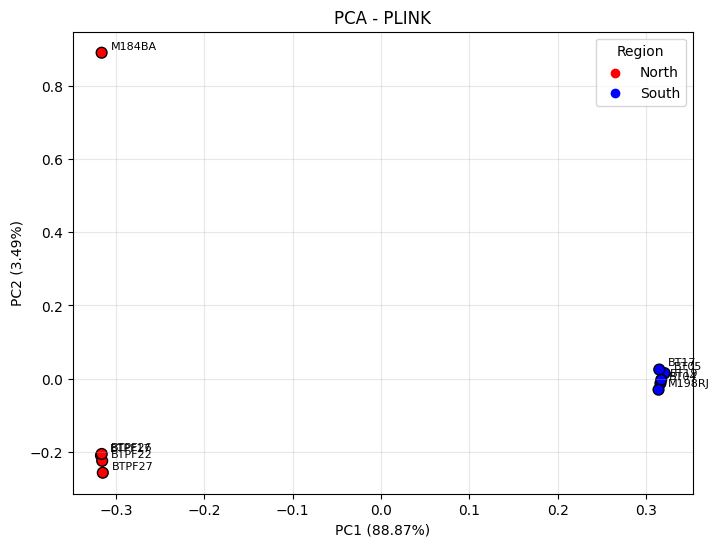

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Ler arquivos
evec = pd.read_csv(
    f"{out_dir_plink}/{name}.pruned.eigenvec",
    sep=r"\s+",
    header=None
)

evals = pd.read_csv(
    f"{out_dir_plink}/{name}.pruned.eigenval",
    sep=r"\s+",
    header=None
)

meta = pd.read_csv(metadata)

output_pdf = f"{out_dir_plink}/{name}.pruned.pc1-2.pdf"

# Renomear colunas dos PCs
npcs = evals.shape[0]
cols = ["FID", "IID"] + [f"PC{i+1}" for i in range(npcs)]
evec.columns = cols

# Juntar PCA com metadados
df = evec.merge(meta, left_on="IID", right_on="SampleID")

# Variância explicada
var_explained = evals[0] / evals[0].sum() * 100

# Cores dos grupos
color_map = {
    "North": "red",
    "South": "blue"
}

df["Color"] = df["Biome"].map(color_map)

# Plot
plt.figure(figsize=(8, 6))

plt.scatter(
    df["PC1"],
    df["PC2"],
    c=df["Color"],
    s=60,
    edgecolors="black"
)

# Rótulos das amostras
for _, row in df.iterrows():
    plt.text(
        row["PC1"] + 0.01,
        row["PC2"] + 0.01,
        row["IID"],
        fontsize=8
    )

# Legenda
for biome, color in color_map.items():
    plt.scatter([], [], c=color, label=biome)

plt.legend(title="Region")

# Eixos e título
plt.xlabel(f"PC1 ({var_explained[0]:.2f}%)")
plt.ylabel(f"PC2 ({var_explained[1]:.2f}%)")
plt.title("PCA - PLINK")
plt.grid(alpha=0.3)

# Salvar figura
plt.savefig(output_pdf, bbox_inches="tight")
plt.show()

> **🦥❓ Questões:**
>
> **a)** Quantos sítios haviam no VCF e quantos deles são considerados não ligados?
>
> **b)** O que os eigenvalues representam?
>
> **c)** Como você interpreta o resultado da PCA?

---
## 3. Rodando Admixture
Como também vimos em aula teórica, o [Admixture](https://dalexander.github.io/admixture/admixture-manual.pdf) é um programa que estima proporção de ancestralidade global baseada em modelos (número de *k*), utilizando genótipo estimados a partir de SNPs de indivíduos não relacionados. Nesse tutorial vamos modelar de duas à quatro populações ancestrais, ou seja *k* de 2-4. E para cada modelagem vamos estimar o *cross-validation (CV) error*, que indica a capacidade/precisão de predição do modelo *k*, mostrando melhor predição para o *k* com menor o *CV error*.



#### 3.1) Preparando arquivos
Uma das formas de rodar o Admixture é usando arquivos de genótipos gerados pelo PLINK, sendo eles `*.bim`, `*.bed` e `*.fam`. Entretando, uma pequena modificação no arquivo `*.bim` é necessária, pois o Admixture não aceita nomes de cromossomos que não estejam no fomato de nome do genoma humano.

In [ ]:
# Editar a primeira coluna do arquivo bim, substituindo os valores por 0
open(f"{out_dir_admx}/{name}.pruned.bim","w").writelines(
    "\t".join(["0"]+line.strip().split()[1:])+"\n" for line in open(f"{out_dir_plink}/{name}.pruned.bim")
)

# Copiar os demais arquivos
!cp {out_dir_plink}/{name}.pruned.bed {out_dir_plink}/{name}.pruned.fam {out_dir_admx}

In [ ]:
# Visualizar
!head {out_dir_admx}/{name}.pruned.bim

0	manual_scaffold_14:11126	0	11126	C	T
0	manual_scaffold_14:62911	0	62911	G	A
0	manual_scaffold_14:120027	0	120027	T	C
0	manual_scaffold_14:176903	0	176903	A	G
0	manual_scaffold_14:242921	0	242921	A	G
0	manual_scaffold_14:314271	0	314271	C	T
0	manual_scaffold_14:340537	0	340537	A	G
0	manual_scaffold_14:392564	0	392564	C	T
0	manual_scaffold_14:457475	0	457475	A	C
0	manual_scaffold_14:593129	0	593129	C	G


Conteúdo das 6 colunas do arquivo `*.bim`:

1.   ID do cromossomo
2.   ID do SNP
3.   Posição em morgans ou centimorgans (pode ser 0)
4.   Posição em pares de base (coordenada)
5.   Alelo 1 (geralmente minor)
6.   Alelo 2 (geralmente major)

#### 3.2) Estimando proporções de ancestralidade
Temos que rodar o comando do Admixture para cada modelo (valor de *k*), utilizando de input o arquivo `*.bed` (com os arquivos `*.fam` e `*.bim` na mesma pasta e com o mesmo prefixo!) gerado pelo PLINK pós filtro de LD.

Abaixo a explicação dos parâmetros usados:

    --cv : enable cross-validation error; In this default setting, the cross-validation procedure will perform 5-fold CV—you can get 10-fold CV, for example, using --cv=10.
    k : number of ancestral populations to be modeled.

In [ ]:
# Rodar Admixture para k=2
!conda run -n structure \
admixture --cv {out_dir_admx}/{name}.pruned.bed 2 > {out_dir_admx}/{name}.pruned.2.log

In [ ]:
# Rodar Admixture para k=3
!conda run -n structure \
admixture --cv {out_dir_admx}/{name}.pruned.bed 3 > {out_dir_admx}/{name}.pruned.3.log

In [ ]:
# Rodar Admixture para k=4
!conda run -n structure \
admixture --cv {out_dir_admx}/{name}.pruned.bed 4 > {out_dir_admx}/{name}.pruned.4.log

In [ ]:
# Listar os arquivos gerados
!ls

# Mover arquivo de saída para pasta desejada (etapa necessaria APENAS pq estamos rodando no colab)
!mv *.Q *.P {out_dir_admx}/

bradypus.pruned.2.P  bradypus.pruned.3.P  bradypus.pruned.4.P  drive
bradypus.pruned.2.Q  bradypus.pruned.3.Q  bradypus.pruned.4.Q  sample_data


Conteúdo dos arquivos gerados:

- `*.Q`: arquivo com k colunas, onde cada linha é um indivíduo (mesma ordem do arquivo [*.fam](https://)) e cada coluna é a porporção de ancestralidade do indivíduo pertencente a cada população inferida.
- `*.P`: arquivo com k colunas, onde cada linha é um SNP e cada coluna é a frequencia dos alelos para população ancestral inferida.

In [ ]:
# Vamos conferir o numero de linhas dos arquivos .P
!wc -l {out_dir_admx}/{name}.pruned.*.P

  4952 drive/MyDrive/PopGen_UFMG_2026/analyses/06_PopStructure/admixture/bradypus.pruned.2.P
  4952 drive/MyDrive/PopGen_UFMG_2026/analyses/06_PopStructure/admixture/bradypus.pruned.3.P
  4952 drive/MyDrive/PopGen_UFMG_2026/analyses/06_PopStructure/admixture/bradypus.pruned.4.P
 14856 total


In [ ]:
# Vamos visualizar as primeiras linhas de um arquivo P, como exemplo
!head {out_dir_admx}/{name}.pruned.2.P

0.000018 0.999990
0.000010 0.999990
0.000014 0.999990
0.000010 0.999990
0.000010 0.999990
0.000010 0.999990
0.999990 0.900000
0.000010 0.999990
0.000010 0.999990
0.999990 0.900000


In [ ]:
# Agora vamos visualizar as primeiras linhas do arquivo Q para o k=2
!head {out_dir_admx}/{name}.pruned.2.Q

0.000010 0.999990
0.000010 0.999990
0.000010 0.999990
0.000010 0.999990
0.999990 0.000010
0.999990 0.000010
0.999990 0.000010
0.999990 0.000010
0.999990 0.000010
0.000010 0.999990


In [ ]:
# Agora vamos visualizar as primeiras linhas do arquivo Q para o k=3
!head {out_dir_admx}/{name}.pruned.3.Q

0.000010 0.999980 0.000010
0.000010 0.000010 0.999980
0.000010 0.000010 0.999980
0.000010 0.999980 0.000010
0.999980 0.000010 0.000010
0.999980 0.000010 0.000010
0.999980 0.000010 0.000010
0.999980 0.000010 0.000010
0.999980 0.000010 0.000010
0.000010 0.000010 0.999980


In [ ]:
# Agora vamos visualizar as primeiras linhas do arquivo Q para o k=4
!head {out_dir_admx}/{name}.pruned.4.Q

0.000010 0.999970 0.000010 0.000010
0.975500 0.024480 0.000010 0.000010
0.967140 0.032840 0.000010 0.000010
0.986198 0.013782 0.000010 0.000010
0.000010 0.000010 0.993612 0.006368
0.000010 0.000010 0.999970 0.000010
0.000010 0.000010 0.996727 0.003253
0.000010 0.000010 0.995837 0.004143
0.000010 0.000010 0.000010 0.999970
0.000010 0.999970 0.000010 0.000010


#### 3.3) Plotando resultados
Para plotar os resultados, vamos usar scripts em Python. O que queremos é gerar um gráfico de distribuição de *CV error*, para avaliar qual o melhor *k* modelado para o nosso conjunto de dados, e um gráfico em barra para cada *k* modelado.

Para plotar o CV, primeiro precisamos pegar esse valor que está no arquivo `*.log` da corrida do Admixture (como já vimos anteriormente). O script abaixo faz isso, salva esses valores em um arquivo `*.txt` e depois faz o plot e salva em um `*.pdf`. Nas linhas 7-9 estão os nomes dos arquivos de entrada e saída, sendo que todos os arquivos log podem ser lidos de uma só vez.

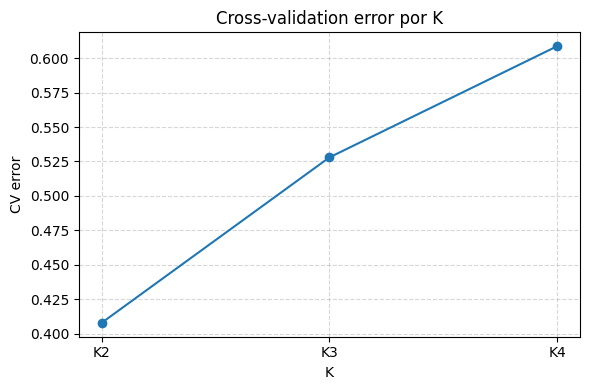

In [ ]:
### Pegar e plotar valores do CV error
import glob, re
import matplotlib.pyplot as plt
import pandas as pd

# arquivos de entrada e saida
log_files = glob.glob(f"{out_dir_admx}/{name}.pruned.*.log")
outfile = f"{out_dir_admx}/{name}.pruned.cverror.txt"
output_pdf = f"{out_dir_admx}/{name}.pruned.cverror.pdf"

# salvar CV em um arquivo
with open(outfile, "w") as fout:
    for log in log_files:
        with open(log) as fin:
            for line in fin:
                if "CV error" in line:
                    parts = line.strip().split()
                    if len(parts) >= 4:
                        # pega colunas 3 e 4
                        cv = parts[2] + " " + parts[3]
                        # remove (), =, :
                        cv_clean = re.sub(r"[()=:]", "", cv)
                        fout.write(cv_clean + "\n")

# preparar dataframe para plotar
df = pd.read_csv(f"{out_dir_admx}/{name}.pruned.cverror.txt", sep=r"\s+", header=None, names=["K", "CV"])

# plotar
plt.figure(figsize=(6,4))
plt.plot(df["K"], df["CV"], marker="o", linestyle="-")
plt.xlabel("K")
plt.ylabel("CV error")
plt.title("Cross-validation error por K")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(output_pdf, bbox_inches='tight')
plt.show()

Para fazer os gráficos de barra de cada análise, precisamos dos arquivos `*.Q` (de todos os valores de *k*) e novamente do arquivo de `metadados`. O script abaixo recebe os metadados na linha 8, o range de valores de k a serem plotados nas linhas 9-10, e o padrão do nome dos arquivos `*.Q` na linha 17. Então, ele plota os resultados, ordenando os indivíduos por população.

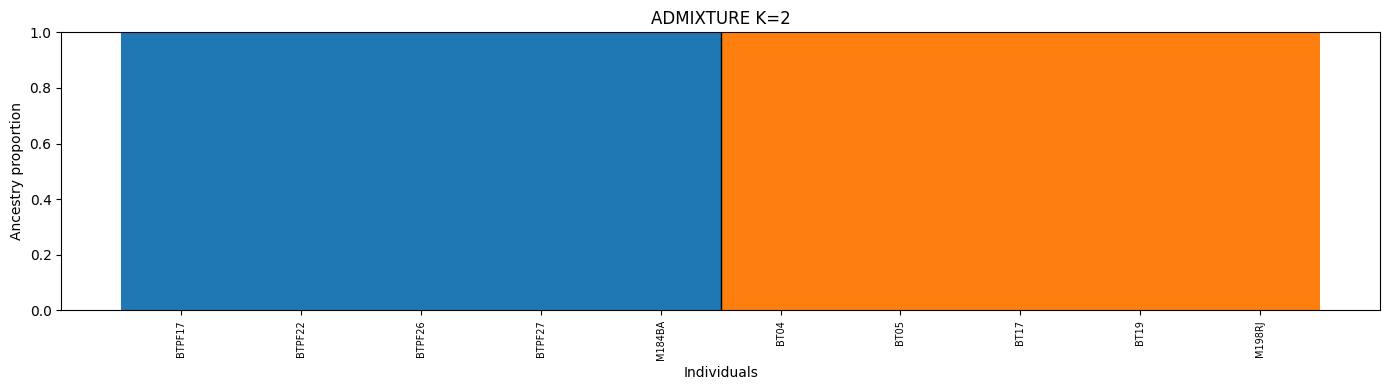

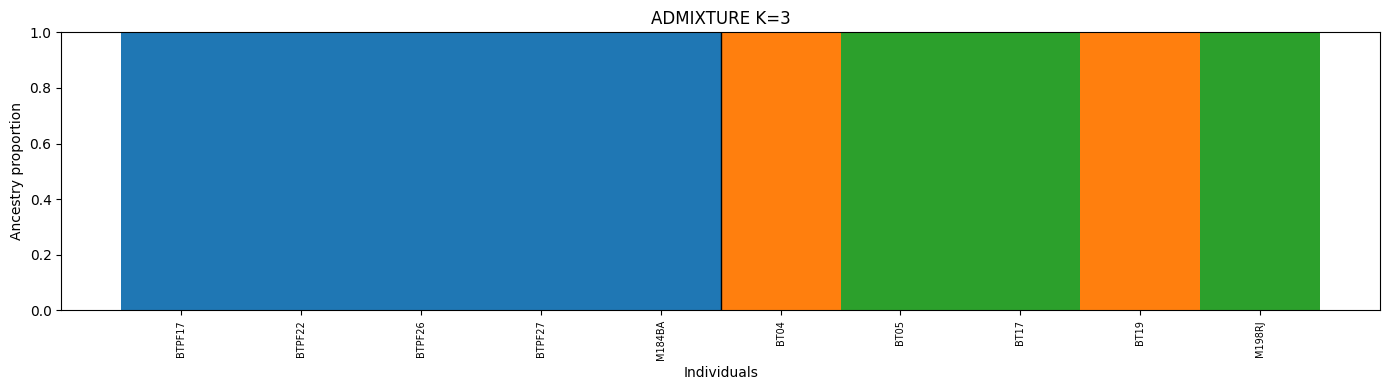

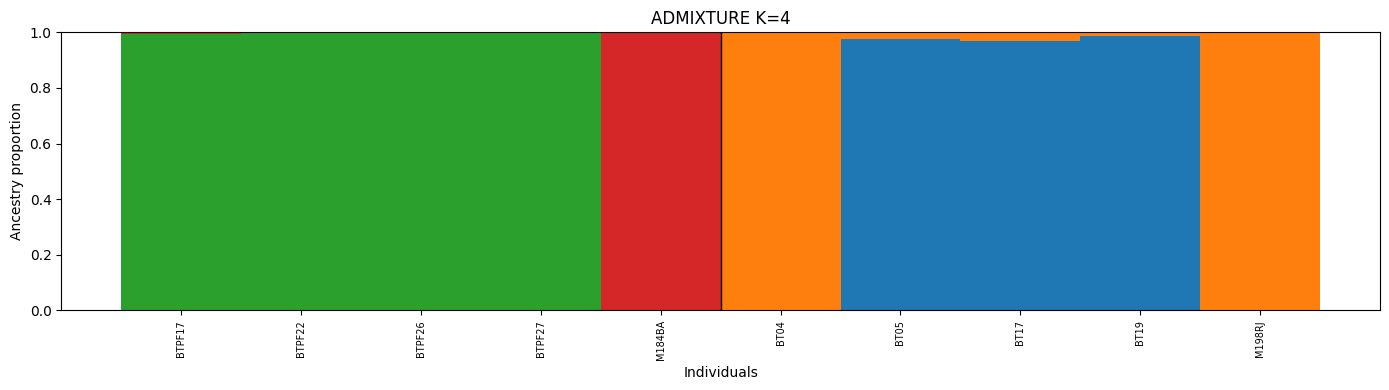

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# =========================
# Ler metadata
# =========================
meta = pd.read_csv(metadata)

# Garantir unicidade dos IDs
meta = meta.drop_duplicates(subset="SampleID")
meta = meta.set_index("SampleID")

# =========================
# Ler ordem dos indivíduos
# utilizada pelo ADMIXTURE
# =========================
fam = pd.read_csv(
    f"{out_dir_plink}/{name}.pruned.fam",
    sep=r"\s+",
    header=None
)

fam.columns = ["FID", "IID", "PID", "MID", "SEX", "PHENO"]

# Verificar se todos os indivíduos do .fam estão no metadata
missing = set(fam["IID"]) - set(meta.index)

if len(missing) > 0:
    raise ValueError(
        f"{len(missing)} indivíduos do .fam não encontrados no metadata:\n{missing}"
    )

# Reordenar metadata na mesma ordem do .fam
meta_ordered = meta.loc[fam["IID"]]

# =========================
# Valores de K
# =========================
k_min = 2
k_max = 4

for K in range(k_min, k_max + 1):

    q_file = f"{out_dir_admx}/{name}.pruned.{K}.Q"

    if not os.path.exists(q_file):
        print(f"Arquivo {q_file} não encontrado, pulando K={K}")
        continue

    # =========================
    # Ler arquivo Q
    # =========================
    q = pd.read_csv(q_file, sep=r"\s+", header=None)

    # Associar corretamente os indivíduos
    q.index = fam["IID"]

    # Adicionar informação do biome
    q["Biome"] = meta_ordered["Biome"]

    # Ordenar por biome
    q_sorted = q.sort_values("Biome")

    biomes_sorted = q_sorted["Biome"]
    sample_ids = q_sorted.index

    # Remover coluna auxiliar
    q_plot = q_sorted.drop(columns="Biome")

    # =========================
    # Plot ADMIXTURE
    # =========================
    plt.figure(figsize=(14, 4))

    bottom = np.zeros(len(q_plot))

    ancestry_colors = plt.get_cmap("tab10").colors

    for i in range(K):
        plt.bar(
            range(len(q_plot)),
            q_plot[i],
            bottom=bottom,
            color=ancestry_colors[i],
            edgecolor="none",
            width=1.0
        )

        bottom += q_plot[i].values

    # =========================
    # Linhas separando os biomas
    # =========================
    biome_changes = np.where(
        biomes_sorted.values[:-1] != biomes_sorted.values[1:]
    )[0]

    for idx in biome_changes:
        plt.axvline(
            idx + 0.5,
            color="black",
            linewidth=1
        )

    # =========================
    # Ajustes do gráfico
    # =========================
    plt.xticks(
        range(len(sample_ids)),
        sample_ids,
        rotation=90,
        fontsize=7
    )

    plt.ylabel("Ancestry proportion")
    plt.xlabel("Individuals")
    plt.title(f"ADMIXTURE K={K}")

    plt.ylim(0, 1)
    plt.tight_layout()

    plt.show()

> **🦥❓ Questões:**
>
> **a)** O que contém nor arquivos P e Q gerados pelo Admixture?
>
> **b)** Como interpretar o CV error?
>
> **c)** Como você interpreta os resultados do Admixture, e qual modelo melhor representa os dados?